<h1> Experiment anti HOM probability against bandwith </h1>

In [3]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_bandwith import run_coincidence_vs_bandwith

<h2> Execute the experiment </h2>

In [4]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Order of the bare parameters
n = 2

#Different photon frequencies
omega_q_tab = [10*pi, 9*pi, 8*pi, 7*pi, 6*pi, 5*pi]

delta_q = 0.05*pi

#Prepare a tab of IR and UV cutoffs for each experiment
nb_pts_bandwith = 15
ir_tab_list = []
uv_tab_list = []
#Experiments 1,2,3,4,5,6 : IR cutoff fixed, UV increased
ir_values = [0*pi, pi, 2*pi, 3*pi, 4*pi, 5*pi]
for i in range(6):
    ir_tab_list.append(ir_values[i] * np.ones(nb_pts_bandwith))
    uv_tab_list.append(np.linspace(ir_values[i] + 2*pi, 30*pi, nb_pts_bandwith))

#Experiments 7,8,9,10,11,12 : central frequency fixed, bandwith increased
central_freqs = [10*pi, 9*pi, 8*pi, 7*pi, 6*pi, 5*pi]
for i in range(6):
    bandwith_tab = np.linspace(pi, central_freqs[i], nb_pts_bandwith)
    ir_tab_list.append(central_freqs[i] - bandwith_tab)
    uv_tab_list.append(central_freqs[i] + bandwith_tab)

Run the experiment

In [5]:
index_omega_q_to_run = [4, 6]
xp_to_run = [1,2,3,7,8,9]

for index_omega_q in index_omega_q_to_run:
        for index_experiment in xp_to_run:
                print(f"Running index omega q {index_omega_q} for frequency window {index_experiment}")

                omega_q = omega_q_tab[index_omega_q-1]

                i = index_experiment - 1

                ir_tab = ir_tab_list[i]
                uv_tab = uv_tab_list[i]

                #Parameters of the simulation
                L = 50

                param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

                param_time_evol = {'T': L/2, 'dt': 0.01}

                param_photons = {'omega_p': [omega_q, omega_q], 
                                'delta_k': [delta_q, delta_q],
                                'x_0': [-L/4, -L/4]}
                        
                _, _, coincidence_tab = run_coincidence_vs_bandwith(param_photons, param_cavity_physical, param_time_evol, ir_tab, uv_tab, 
                                                                index_omega_q, index_experiment, n=n)
                
                print("------------- \n")

Running index omega q 4 for frequency window 1


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [25:43<00:00, 102.87s/it]


------------- 

Running index omega q 4 for frequency window 2


  0%|          | 0/15 [00:00<?, ?it/s]

...

100%|██████████| 15/15 [1:33:07<00:00, 372.49s/it]


------------- 

Running index omega q 6 for frequency window 9


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [51:00<00:00, 204.03s/it]

------------- 



<h2> Convergence per truncation scheme </h2>

Recover the data

In [48]:
index_experiment = 9
n_value = 2

coincidence_to_plot = []
omega_available = []
bandwith_to_plot = []
theoretical_val_list = []
relative_error_list = []

for j in range(len(omega_q_tab)):
    try:
        index_omega_q = j+1

        data_file = f"../results/csv_files/coincidence_vs_bandwidth/coincidence_vs_bandwith_omega{index_omega_q}_xp{index_experiment}_n{n_value}.csv"

        df = pd.read_csv(data_file)
        coincidence_tab = df['coincidence_tab'].to_numpy()
        ir_tab = df['ir_tab'].to_numpy()
        uv_tab = df['uv_tab'].to_numpy()

        R_theory_physical = 1 / (1 + ((omega_q_tab[index_omega_q-1] - omega_A)/ (Gamma/2))**2)
        theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

        #non monochromatic correction
        if np.abs(theoretical_val) < 1e-1:
            non_monochr_ratio = Gamma / (2*delta_q)
            theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)

        coincidence_to_plot.append(coincidence_tab)
        omega_available.append(j)
        bandwith_to_plot.append(uv_tab - ir_tab)
        theoretical_val_list.append(theoretical_val)
        relative_error_list.append(np.abs(coincidence_to_plot[-1][-1] - theoretical_val_list[-1])/theoretical_val_list[-1])

    
    except Exception:
        print(f'omega_q index {index_omega_q} not available')
        continue

omega_q index 1 not available
omega_q index 3 not available
omega_q index 4 not available
omega_q index 5 not available
omega_q index 6 not available


Create the figure

Relative error for omega_q = 9.0 pi: 7.856 %


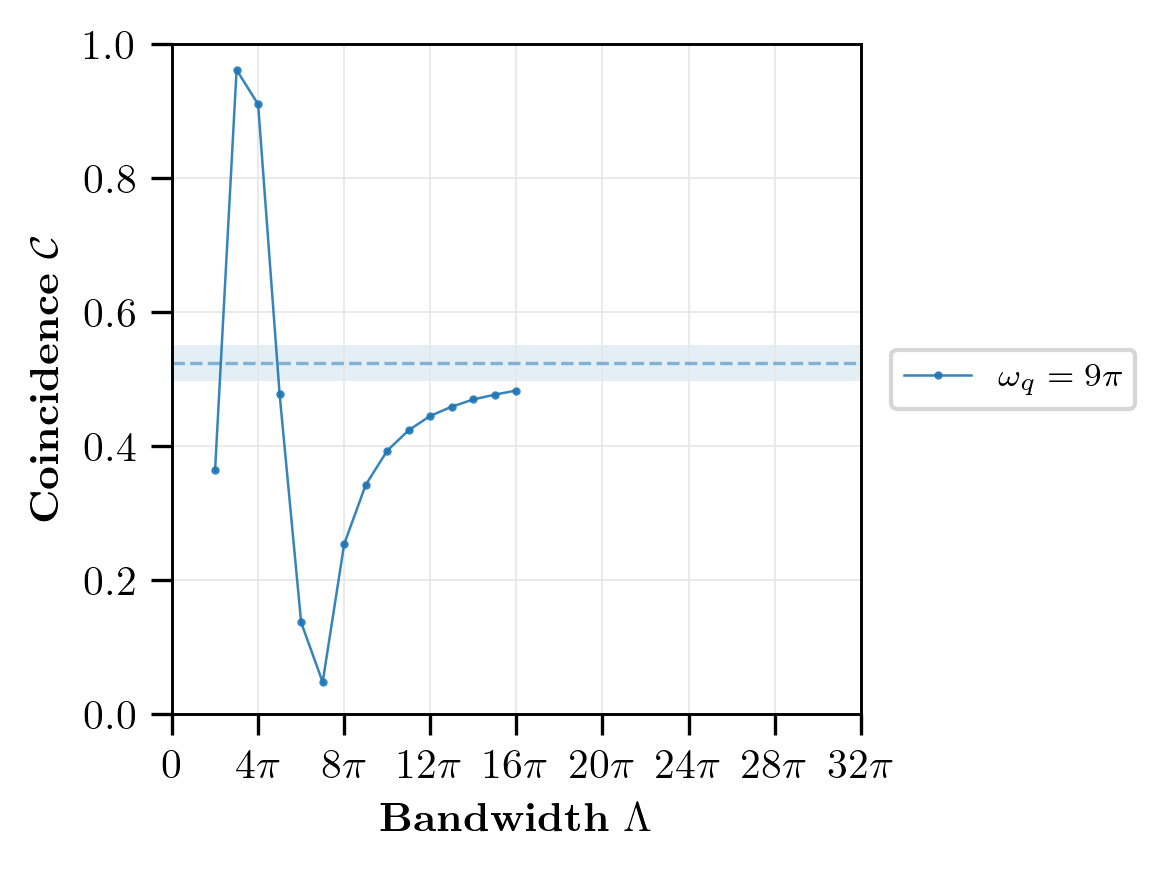

In [49]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Palette sobre + markers distincts

labels  = [r'$\omega_q = 10\pi$', r'$\omega_q = 9\pi$', r'$\omega_q = 8\pi$', r'$\omega_q = 7\pi$', r'$\omega_q = 6\pi$', r'$\omega_q = 5\pi$']

lbda_conv = np.zeros(len(omega_available))

# Scatter plots
for j in range(len(omega_available)):

    print(f"Relative error for omega_q = {omega_q_tab[omega_available[j]]/pi:.1f} pi: {relative_error_list[j]*100:.3f} %")
    #Index where the curve enters the 5% confidence region
    if (coincidence_to_plot[j][-1] > 0.95*theoretical_val_list[j] and coincidence_to_plot[j][-1] < 1.05 * theoretical_val_list[j]):
        lbda_conv[j] = bandwith_to_plot[j][np.where((coincidence_to_plot[j] < 1.05*theoretical_val_list[j]) & 
                                                    (coincidence_to_plot[j] > 0.95*theoretical_val_list[j]))[0][0]]
        labels[j] += '(O)'
    else:
        lbda_conv[j] = np.inf
        labels[j] += '(X)'

    ax.plot(
        bandwith_to_plot[j],
        coincidence_to_plot[j],
        marker="o",
        label = labels[omega_available[j]],
        markersize=1,
        linewidth=0.6,
        alpha=0.9,
        zorder=3
    )
    #5% confidence region
    ax.hlines(theoretical_val_list[j], 0, 100*pi, alpha=0.5, linewidth=0.8, linestyle='--')
    ax.fill_between(np.linspace(0, 100*pi, 100),
                    0.95*theoretical_val_list[j],
                    1.05*theoretical_val_list[j],alpha=0.12,linewidth=0, zorder=1)

#Indicate largest lbda_conv if non nan (ie all curves enter the confidence region)
max_lbda_conv = np.max(lbda_conv)
if not np.isinf(max_lbda_conv):
    #Display numerical lbda_conv in pi units
    ax.text(
        1.1 * max_lbda_conv/(32*pi),
        0.85,
        r'$\Lambda_{\mathrm{conv}} \approx ' + f"{max_lbda_conv/pi:.1f}" + r'\pi$',
        color='black',
        fontsize=9,
        va='center',
        ha='left',
        transform=ax.get_yaxis_transform()
    )
    ax.vlines(max_lbda_conv, 0, 1, color='black', alpha=0.5, linestyle='--', linewidth=0.8)

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=True,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)


ax.set_xlim([0, 32*pi])
# Espacement des ticks (ici tous les 2π)
ax.xaxis.set_major_locator(MultipleLocator(4*np.pi))

# Formatage automatique en unités de π
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

ax.set_ylim([0,1])

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=13)
ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
#ax.legend(prop={'size': 8}, frameon=False, loc="best")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
#plt.savefig(f'../results/fig/coincidence_vs_bandwith_xp_{index_experiment}.pdf', bbox_inches="tight")
plt.show()